In [ ]:
from google.colab import files
files.upload()   # Upload the kaggle.json file you downloaded

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Check if kaggle is working
!kaggle datasets list | head

ref                                                           title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset  Global Earthquake-Tsunami Risk Assessment Dataset       16151  2025-10-01 16:35:53.273000           4127        152  1.0              
jockeroika/life-style-data                                    Life Style Data                                       3995645  2025-10-14 13:50:45.303000           5392        124  0.8235294        
ahmadrazakashif/bmw-worldwide-sales-records-20102024          BMW Worldwide Sales Records (2010–2024)                853348  2025-09-20 14:39:45.280000          10080        222  1.0              
jaderz/hospital

In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip skin-cancer-mnist-ham10000.zip -d /content/HAM10000

Streaming output truncated to the last 5000 lines.
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029325.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029337.jpg  


In [ ]:
import os, shutil, glob

combined_path = '/content/HAM10000/images'
os.makedirs(combined_path, exist_ok=True)

for folder in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
    for f in glob.glob(f'/content/HAM10000/{folder}/*.*'):
        shutil.copy(f, combined_path)

print("Total original images:", len(glob.glob(os.path.join(combined_path, '*.*'))))

Total original images: 10015


In [ ]:
from PIL import Image, ImageOps, ImageEnhance
import random

target_count = 20000
imgs = glob.glob(os.path.join(combined_path, '*.*'))
i = 0

while len(glob.glob(os.path.join(combined_path, '*.*'))) < target_count:
    src = random.choice(imgs)
    im = Image.open(src).convert('RGB')

    if random.random() < 0.5:
        im = ImageOps.mirror(im)
    if random.random() < 0.5:
        im = im.rotate(random.choice([90, 180, 270]))
    if random.random() < 0.5:
        enhancer = ImageEnhance.Color(im)
        im = enhancer.enhance(0.8 + random.random()*0.8)

    out_path = os.path.join(combined_path, f'aug_{i:06d}.jpg')
    im.save(out_path)
    i += 1

print("Total images after augmentation:", len(glob.glob(os.path.join(combined_path, '*.*'))))

Total images after augmentation: 20000


In [ ]:
# =====================================
# 🚀 Improved VAE Training on HAM10000
# =====================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
import os

# ----------------------
# Paths
# ----------------------
combined_path = '/content/HAM10000/images'  # your augmented images folder
os.makedirs("outputs/vae_samples", exist_ok=True)
os.makedirs("outputs/fid_samples/vae", exist_ok=True)

# ----------------------
# Custom Dataset (no class folders needed)
# ----------------------
class ImageFolderDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_paths = [os.path.join(img_dir, f) for f in os.listdir(img_dir)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, 0  # dummy label

# ----------------------
# Transform & Dataloader
# ----------------------
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # increase to 128x128 if GPU allows
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # [-1,1]
])

dataset = ImageFolderDataset(img_dir=combined_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)

print("Total images in dataset:", len(dataset))

# ----------------------
# VAE Model Definition
# ----------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=256):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),    # 64x64 -> 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),   # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # 16x16 -> 8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), # 8x8 -> 4x4
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(256*4*4, latent_dim)
        self.fc_logvar = nn.Linear(256*4*4, latent_dim)

        # Decoder
        self.fc_dec = nn.Linear(latent_dim, 256*4*4)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 4x4 -> 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 16x16 -> 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),    # 32x32 -> 64x64
            nn.Tanh()
        )

    def encode(self, x):
        h = self.enc(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(-1, 256, 4, 4)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

# ----------------------
# Loss Function (β-VAE)
# ----------------------
beta = 0.5  # tweak 0.3-0.7 for sharper images

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss

# ----------------------
# Training
# ----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE(latent_dim=256).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
epochs = 98

for epoch in range(epochs):
    vae.train()
    total_loss = 0
    for imgs, _ in dataloader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = vae(imgs)
        loss = vae_loss(recon, imgs, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(dataset):.4f}")

    # Save a few reconstructed images for monitoring
    vae.eval()
    with torch.no_grad():
        sample = recon[:16]
        sample = (sample + 1)/2  # [0,1]
        save_image(sample, f"outputs/vae_samples/recon_epoch_{epoch+1}.png", nrow=4)

# ----------------------
# Generate Synthetic Images for FID
# ----------------------
vae.eval()
with torch.no_grad():
    z = torch.randn(1000, vae.latent_dim).to(device)
    samples = vae.decode(z)
    samples = (samples + 1)/2  # [0,1]
    for i in range(samples.size(0)):
        save_image(samples[i], f"outputs/fid_samples/vae/sample_{i:04d}.png")

print("VAE training and sample generation completed ✅")

Total images in dataset: 20000
Epoch [1/98], Loss: 619.9775
Epoch [2/98], Loss: 204.2672
Epoch [3/98], Loss: 163.3456
Epoch [4/98], Loss: 148.7326
Epoch [5/98], Loss: 135.3103
Epoch [6/98], Loss: 124.0253
Epoch [7/98], Loss: 124.4523
Epoch [8/98], Loss: 115.1137
Epoch [9/98], Loss: 113.9002
Epoch [10/98], Loss: 115.0943
Epoch [11/98], Loss: 108.9691
Epoch [12/98], Loss: 109.9673
Epoch [13/98], Loss: 104.9360
Epoch [14/98], Loss: 107.6976
Epoch [15/98], Loss: 102.4894
Epoch [16/98], Loss: 105.4861
Epoch [17/98], Loss: 101.7799
Epoch [18/98], Loss: 106.4009
Epoch [19/98], Loss: 100.6022
Epoch [20/98], Loss: 103.4204
Epoch [21/98], Loss: 99.5871
Epoch [22/98], Loss: 98.5945
Epoch [23/98], Loss: 98.6004
Epoch [24/98], Loss: 100.2167
Epoch [25/98], Loss: 98.4321
Epoch [26/98], Loss: 96.3790
Epoch [27/98], Loss: 97.2971
Epoch [28/98], Loss: 97.2200
Epoch [29/98], Loss: 99.4633
Epoch [30/98], Loss: 96.8823
Epoch [31/98], Loss: 96.3068
Epoch [32/98], Loss: 96.9010
Epoch [33/98], Loss: 96.2885


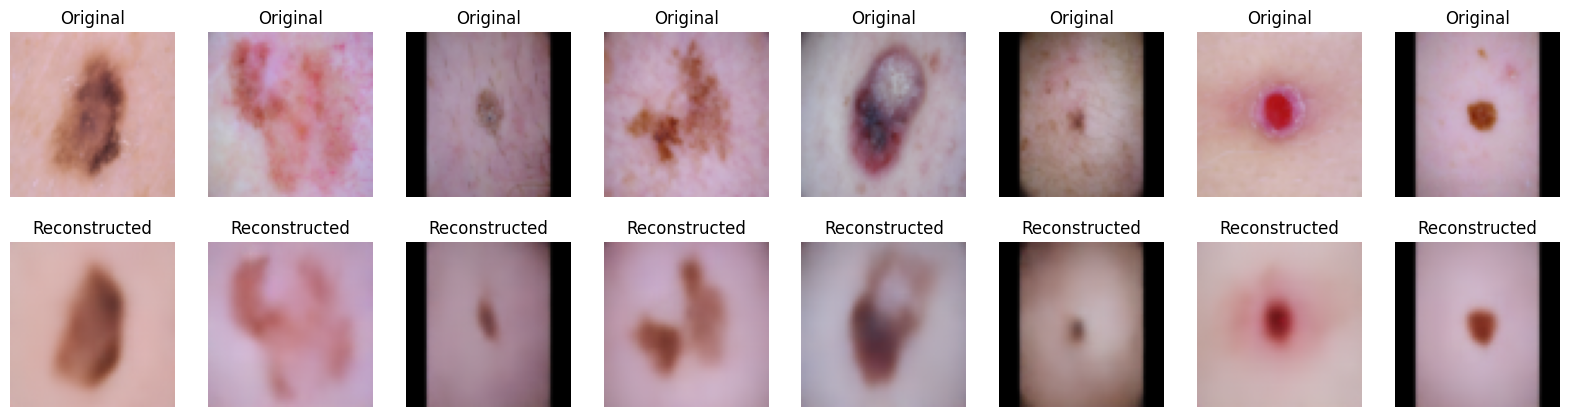

In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Load a batch from the last reconstruction
vae.eval()
with torch.no_grad():
    for imgs, _ in dataloader:
        imgs = imgs.to(device)
        recon, _, _ = vae(imgs)
        break  # take only first batch

# Denormalize images from [-1,1] to [0,1]
recon = (recon + 1)/2
imgs = (imgs + 1)/2

# Display first 8 images: original vs reconstruction
fig, axes = plt.subplots(2, 8, figsize=(20,5))
for i in range(8):
    axes[0,i].imshow(imgs[i].permute(1,2,0).cpu())
    axes[0,i].axis('off')
    axes[0,i].set_title('Original')

    axes[1,i].imshow(recon[i].permute(1,2,0).cpu())
    axes[1,i].axis('off')
    axes[1,i].set_title('Reconstructed')

plt.show()

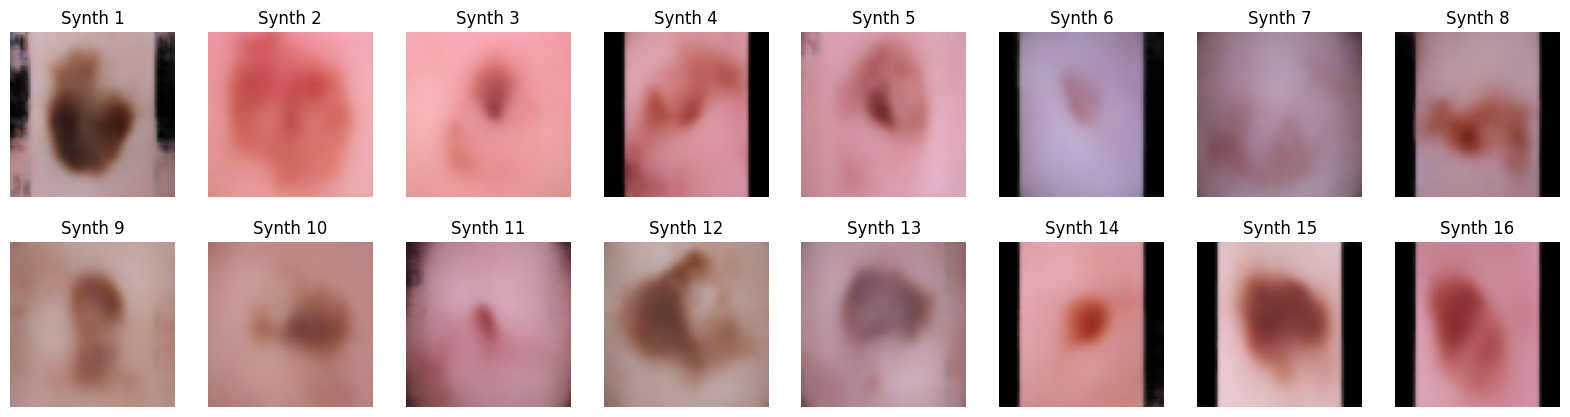

In [ ]:
# Take first 16 synthetic images from outputs/fid_samples/vae/
import torchvision.io as io

synthetic_paths = sorted(glob.glob("outputs/fid_samples/vae/*.png"))[:16]

fig, axes = plt.subplots(2, 8, figsize=(20,5))
for i, path in enumerate(synthetic_paths):
    img = Image.open(path)
    axes[i//8, i%8].imshow(img)
    axes[i//8, i%8].axis('off')
    axes[i//8, i%8].set_title(f'Synth {i+1}')
plt.show()

In [ ]:
!pip install pytorch-fid

from pytorch_fid import fid_score

real_path = combined_path        # original images (augmented set)
fake_path = "outputs/fid_samples/vae"  # generated images

fid_value = fid_score.calculate_fid_given_paths([real_path, fake_path],
                                                batch_size=50,
                                                device=device,
                                                dims=2048)
print("FID:", fid_value)

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:04<00:00, 22.4MB/s]
100%|██████████| 20/20 [00:04<00:00,  4.85it/s]


FID: 262.37448638382136


In [ ]:
!pip install torch-fidelity

In [ ]:
!pip install torchmetrics[image]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 60.8 MB/s eta 0:00:00


In [ ]:
!pip install piq

import piq
# imgs: original batch, recon: reconstructed batch from VAE
ssim_score = piq.ssim(recon, imgs).item()
print("SSIM:", ssim_score)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 10.7 MB/s eta 0:00:00
SSIM: 0.7979782819747925


In [ ]:
!pip install lpips

import lpips
loss_fn = lpips.LPIPS(net='alex').to(device)
lpips_score = loss_fn(recon, imgs).mean().item()
print("LPIPS:", lpips_score)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.5 MB/s eta 0:00:00
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 166MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS: 0.2085854709148407


In [ ]:
!pip install torch-fidelity

from torch_fidelity import calculate_metrics

real_path = combined_path  # your original images folder
fake_path = "outputs/fid_samples/vae"  # VAE generated images

metrics = calculate_metrics(
    input1=real_path,
    input2=fake_path,
    cuda=True,
    isc=True,      # Inception Score
    kid=False,
    verbose=True
)

print("Inception Score:", metrics['inception_score_mean'], "±", metrics['inception_score_std'])

Creating feature extractor "inception-v3-compat" with features ['logits_unbiased']
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:02<00:00, 34.6MB/s]
Extracting features from input1
Looking for samples non-recursivelty in "/content/HAM10000/images" with extensions png,jpg,jpeg
Found 20000 samples, some are lossy-compressed - this may affect metrics
/usr/local/lib/python3.12/dist-packages/torch_fidelity/datasets.py:16: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  img = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes())).view(height, width, 3)
/usr/local

Inception Score: 3.32019601681583 ± 0.058812342984371144


Inception Score: 3.32019601681583 ± 0.058812342984371144
